In [20]:
import casadi as ca
import numpy as np

import matplotlib.pyplot as plt

# Bioreaktor Model: 

Es handelt sich um ein einfaches Modell eines kontinuierlich betriebenen Rührkesselreaktors (CSTR) für die Kultivierung von Mikroorganismen. Das Modell umfasst die folgenden Hauptkomponenten:

1. **Zustandsvariablen:**
   - Konzentration 1 ($X$) [kg/m^3]
   - Konzemtration 2 ($S$) [kg/m^3]
   - Reaktorvolumen ($V$) [m^3]

2. **Parameter:**
   - Konzemtration 2 im Zulauf ($S_{in}$) [kg/m^3]

3. **Eingangsgrößen:**
   - Flowrate der Konzemtration 2 ($F_{in}$) [m^3/s]
   - Flowrate des Reaktors ($F_{out}$) [m^3/s]
4. **Dynamische Gleichungen:**
   $$ \frac{d (V \cdot X)}{dt} = - F_{out} X $$
   $$ \frac{d (V \cdot S)}{dt} =  F_{in} S_{in} - F_{out} S $$
   $$ \frac{d V}{dt} = F_{in} - F_{out} $$

Gleichung 1 beschreibt das Wachstum der Biomasse, während Gleichung 2 die Veränderung der Substratkonzentration im Reaktor darstellt.


In [ ]:
# Bioreactor parameters
S_in = 2.0 # Substratkonzentration

F_in = 1.0 # Flowrate der Substratlösung [m^3/s]
F_out = 1.0 # Flowrate des Reaktors [m^3/s]

# Zustandsvariablen definieren
X = ca.SX.sym('X') # Zellkonzentration
S = ca.SX.sym('S') # Substratkonzentration
V = ca.SX.sym('V') # Reaktorvolumen

# Zustandsvektor
states = ca.vertcat(X, S, V)

dV_dt = F_in - F_out
#  d V x/dt =  dV/dt x + V dx/dt  => dx/dt = (d (V x)/dt - dV/dt x) / V
dx_dt = (- F_out * X - dV_dt * X) / V
#  d V s/dt =  dV/dt s + V ds/dt  => ds/dt = (d (V s)/dt - dV/dt s) / V
ds_dt = ( F_in * S_in - F_out * S - dV_dt * S) / V

# Zustandsraummodell
f = ca.vertcat(dx_dt, ds_dt, dV_dt)


In [28]:
# Simulation erstellen
dt = 0.1 # Zeitschritt
T = 5.0 # Simulationsdauer

# Anfangsbedingungen
X0 = 1.0 # wird upbgedatet vom PioReactor
S0 = 2.0 # wird upbgedatet vom PioReactor
V0 = 10.0

# Integrator erstellen
integrator = ca.integrator('integrator', 'rk', {'x': states, 'ode': f}, {'tf': dt})

# Simulation durchführen
time = np.arange(0, T, dt)
X_sim = [X0]
S_sim = [S0]
V_sim = [V0]

for t in time[1:]:
    res = integrator(x0=ca.vertcat(X_sim[-1], S_sim[-1], V_sim[-1]))
    X_sim.append(float(res['xf'][0]))
    S_sim.append(float(res['xf'][1]))
    V_sim.append(float(res['xf'][2]))


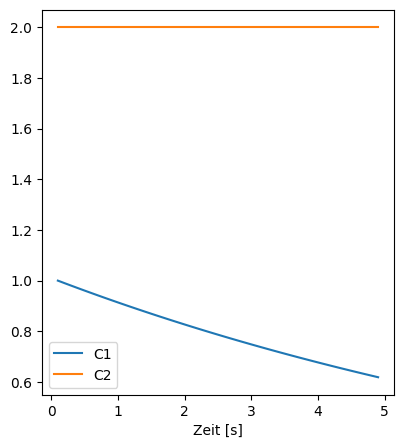

In [ ]:
# Plotten
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(time[1:], X_sim[:-1], label='C1')
plt.plot(time[1:], S_sim[:-1], label='C2')
plt.xlabel('Zeit [s]')
plt.ylabel('optische dichte')
plt.legend()
plt.show()